In [1]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'src'
d = current_dir
for _ in range(5):
    if (d / "src").exists() and (d / "src" / "net_epistemology").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    src_path = str(project_root / "src")
    if src_path not in sys.path:
        sys.path.append(src_path)
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    # Fallback to strict relative path just in case
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'src')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from net_epistemology.utils.imports import *
from net_epistemology.core.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../data/empirical_networks/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../data/empirical_networks/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [4]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [5]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=50000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 50000/50000 [00:11<00:00, 4213.16it/s]


steps:  50000
conclusion:  0.41379310344827586
conclusion core 0.5641025641025641


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,0.905919,0.42529,0.240377,0.872408,0.058921,0.211063,0.754424,0.464255,0.677306,0.578950,...,0.924570,0.347241,0.350323,0.035325,0.983033,0.498437,0.677340,0.703517,0.123213,0.170472
1,0.907945,0.42529,0.246269,0.871515,0.061640,0.211063,0.767518,0.472222,0.677306,0.586731,...,0.923447,0.358199,0.348504,0.037284,0.983166,0.498437,0.679086,0.710148,0.126712,0.184480
2,0.906599,0.42529,0.249251,0.872408,0.062572,0.211063,0.768942,0.476212,0.679052,0.584789,...,0.922880,0.361886,0.353973,0.036714,0.982899,0.498437,0.677340,0.713430,0.125830,0.189343


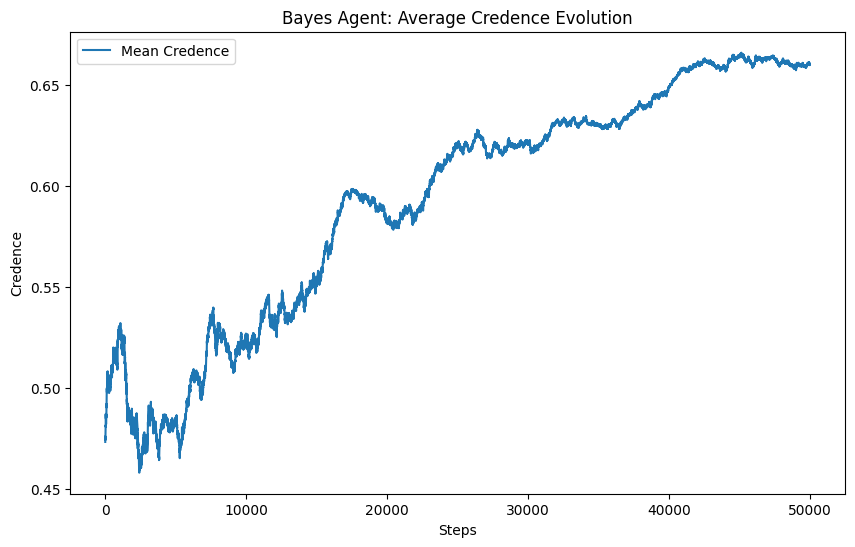

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

 67%|██████▋   | 6722/10000 [00:02<00:01, 2516.88it/s]


steps:  6723
conclusion:  0.45977011494252873


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,"[0.9628455329049892, 0.3909035836372746]","[0.0029735436990289453, 0.27658640117557187]","[0.011980007451599186, 0.8725376889166867]","[0.8007108518820558, 0.960947386108291]","[0.11994855953158495, 0.10211570371217378]","[0.6229463882492765, 0.019002942610192666]","[0.9614983097193419, 0.28458230475753893]","[0.9574058449137307, 0.2631683818721116]","[0.5633544357819359, 0.10755236121551785]","[0.10407284299446064, 0.07526171095660517]",...,"[0.19666137501165884, 0.3621140672589376]","[0.0030844185656567595, 0.6574419435963711]","[0.7867795959796497, 0.8403730302466556]","[0.9991351829448468, 0.8961513351756512]","[0.867473202201413, 0.42381530062866835]","[0.6542230541332948, 0.6021265367852545]","[0.7783736574156523, 0.15490057247228795]","[0.9915718093455155, 0.4780730930592869]","[0.9685725275671112, 0.42324566629153043]","[0.2552047813847424, 0.027062448488385852]"
1,"[0.3569528964957426, 0.3631059375593657]","[0.703554282116589, 0.4995287167128305]","[0.5250432749451478, 0.398466588398961]","[0.8654142693607304, 0.6457033765235979]","[0.3881459153846036, 0.3950398993427046]","[0.5578482859858164, 0.46727670745947975]","[0.3640420837246363, 0.39345507163308624]","[0.5699607889007074, 0.32427121591763264]","[0.6263042735261154, 0.3366008684879636]","[0.5455480374775173, 0.4723315200626695]",...,"[0.5197162154407964, 0.5560713826903955]","[0.3627993556032083, 0.5739127042930882]","[0.6245241324636155, 0.75952846513466]","[0.579861959441667, 0.4643306293898774]","[0.5852472129343828, 0.9199029568689804]","[0.2832141597151262, 0.7059589124669443]","[0.6148273516260052, 0.2762584478648957]","[0.4008104428926302, 0.38475084647106184]","[0.380657674095528, 0.47602603495432627]","[0.5858339480084609, 0.5605906777325337]"
2,"[0.49906937944872354, 0.4278659045462415]","[0.36577286378370305, 0.5368101727899989]","[0.4958286147700285, 0.5631694689470931]","[0.7683098786050699, 0.5603451674337054]","[0.5715817484752206, 0.39495973352624725]","[0.539607104640984, 0.5722466429219342]","[0.4528052313006488, 0.49873482910793704]","[0.5157345287182329, 0.3930787163668614]","[0.3919264043446408, 0.5378226794384936]","[0.4939089281835989, 0.3410380288879427]",...,"[0.46291411125746995, 0.3966444124852548]","[0.4342035380618968, 0.6242308776355705]","[0.5822841770321442, 0.5635292386098254]","[0.39661731073611817, 0.34517961372103767]","[0.6937496856950209, 0.560588880860984]","[0.2828597066721623, 0.3815155235617573]","[0.7579853122829256, 0.46500373480220825]","[0.4848769326431541, 0.41643875057786595]","[0.5992104883370347, 0.31328755537977515]","[0.5488536632080439, 0.38346854529274765]"


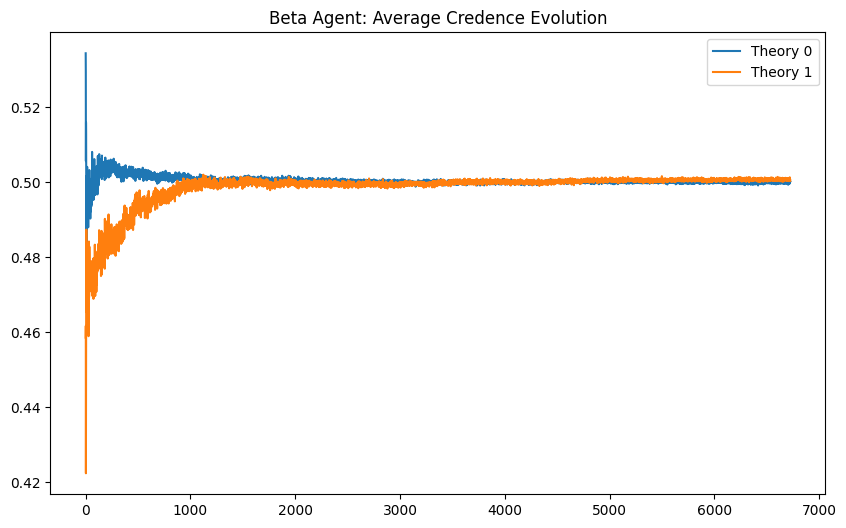

In [8]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

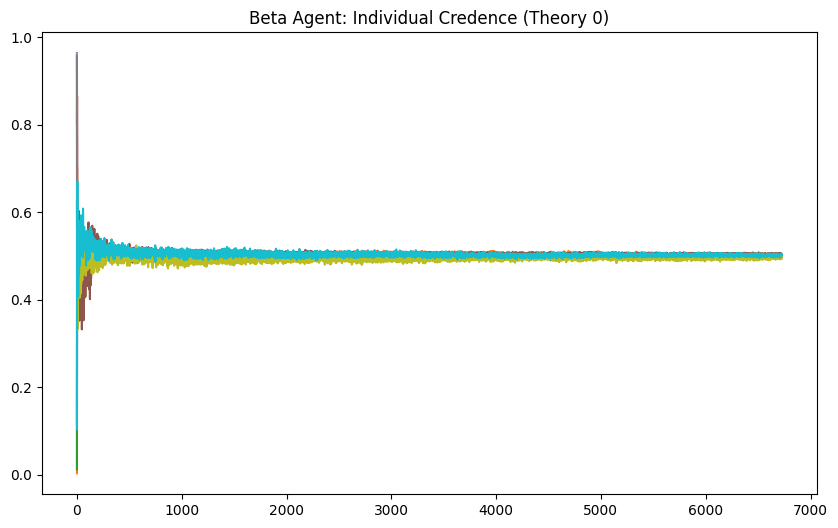

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()